#Lab 2 - Neural Network for Handwritten Digit Recognition
We will not be holding a formal in-class session for Lab 2. Instead, this lab is designed to be completed independently.

Start training...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.


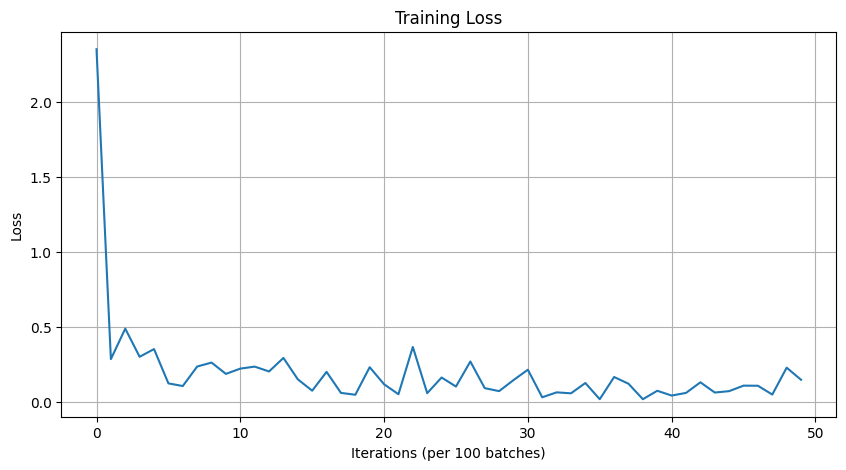

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Setup MNIST Dataset
raw_dataset = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
loader = torch.utils.data.DataLoader(raw_dataset, batch_size=len(raw_dataset))

# Get mean and std from all images
all_images, all_labels = next(iter(loader))
mean, std = all_images.mean().item(), all_images.std().item()

# Normalization for alignment and standardization by
# Normalizing the intensity (mean) and contrast (std)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)

# Define a 2-layer neural network for handwritten digit recognition
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Flatten the raw image from 28x28 to 784x1
        self.flatten = nn.Flatten()
        # Construct the layers of the network
        # nn.Sequential is the container for stacking layers
        self.layers = nn.Sequential(
            # Input layer (784 neurons) -> hidden layer (128 neurons)
            nn.Linear(784, 128),
            # Activation
            nn.ReLU(),
            # Dropout
            nn.Dropout(0.2),
            # Hidden layer (128 neurons) -> output layer (10 neurons)
            nn.Linear(128, 10),

            # Comment out if using criterion = nn.CrossEntropyLoss()
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.003)
# Comment out if using criterion = nn.CrossEntropyLoss()
criterion = nn.NLLLoss()

# Comment out if using nn.LogSoftmax(dim=1) and criterion = nn.NLLLoss()
# criterion = nn.CrossEntropyLoss()

# Training
epochs = 5
losses = []

print("Start training...")
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        output = model(data)
        # Loss function
        loss = criterion(output, target)
        # Backpropagation
        loss.backward()
        # Update parameters
        optimizer.step()

        if batch_idx % 100 == 0:
            losses.append(loss.item())
    print(f"Epoch {epoch+1} complete.")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Iterations (per 100 batches)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

###Drawing Canvas for Testing

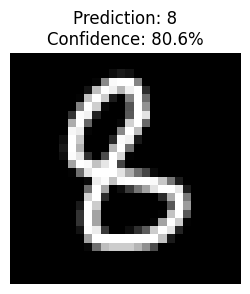

In [ ]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import cv2
import torch
import base64

canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 320px; text-align: center; background-color: #f9f9f9;">
    <canvas id="main_canvas" width="280" height="280" style="border:2px solid #000; cursor: crosshair; background-color: black;"></canvas>
    <br><br>
    <button id="finish_btn" style="padding: 10px 20px; cursor: pointer;">Finish & Predict</button>
</div>
<script>
    var canvas = document.getElementById('main_canvas');
    var ctx = canvas.getContext('2d');
    var button = document.getElementById('finish_btn');
    var drawing = false;

    ctx.strokeStyle = "white";
    ctx.lineWidth = 18;
    ctx.lineCap = "round";

    canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', (e) => { if(drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', () => { drawing = false; });

    // We use a global variable to ensure Colab can pick it up
    var data = new Promise(resolve => {
        button.onclick = () => {
            resolve(canvas.toDataURL('image/png'));
        }
    });
</script>
"""

def get_prediction():
    display(HTML(canvas_html))

    # Wait for the user to click the button
    raw_data = output.eval_js("data")

    # Check if raw_data is a list and extract the string
    if isinstance(raw_data, list):
        data_url = raw_data
    else:
        data_url = raw_data

    # Process Image
    try:
        # Strip the header (data:image/png;base64,)
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)

        nparr = np.frombuffer(binary, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

        # Resize and Normalize
        img_28 = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

        # Preprocessing for the model
        img_tensor = torch.from_numpy(img_28).float()
        img_tensor = (img_tensor / 255.0 - 0.1307) / 0.3081
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

        # Model Prediction
        model.eval()
        with torch.no_grad():
            output_logits = model(img_tensor)
            # comment out if using criterion = nn.CrossEntropyLoss()
            # output_logits = nn.LogSoftmax(dim=1)(output_logits)
            ps = torch.exp(output_logits)
            prob, pred = torch.max(ps, 1)

        # Visual Result
        plt.figure(figsize=(3, 3))
        plt.imshow(img_28, cmap='gray')
        plt.title(f"Prediction: {pred.item()}\nConfidence: {prob.item()*100:.1f}%")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Run the test
get_prediction()